# SepVAE Training Dynamics Sandbox

A self-contained educational notebook that reproduces the training dynamics and failure modes
described in the Multi-head SepVAE Diagnostic Manual.

## Table of Contents
1. [Setup & Configuration](#1-setup--configuration)
2. [Dataset](#2-dataset)
3. [Model Architecture](#3-model-architecture)
4. [Loss Functions](#4-loss-functions)
5. [Training Loop](#5-training-loop)
6. [Diagnostics & Visualization](#6-diagnostics--visualization)
7. [Experiments](#7-experiments)

---

## 1. Setup & Configuration

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
@dataclass
class Config:
    """Configuration for SepVAE training sandbox.
    
    Maps to real SepVAE hyperparameters from the diagnostic manual.
    """
    # Dataset
    dataset: str = 'fashionmnist'  # 'mnist' or 'fashionmnist'
    normal_classes: List[int] = field(default_factory=lambda: [0])  # T-shirt as "normal"
    disease_classes: List[int] = field(default_factory=lambda: [1, 7])  # Trouser, Sneaker as "diseases"
    batch_size: int = 64
    num_samples: int = 3000  # Subset for fast training
    
    # Architecture
    img_size: int = 28
    img_channels: int = 1
    z_dim_common: int = 16      # Common latent dimension (anatomy)
    z_dim_disease: int = 8      # Per-disease head dimension (salient)
    hidden_dim: int = 256       # Encoder/decoder hidden dimension
    
    # Training
    epochs: int = 30
    lr_vae: float = 1e-3
    lr_mi_disc: float = 1e-4
    
    # Loss weights (mirrors --weight_* from SepVAE)
    weight_rec: float = 1.0
    weight_kl_common: float = 1e-3
    weight_kl_disease: float = 1e-3
    weight_null: float = 1e-2
    weight_mi: float = 1e-3
    weight_perceptual: float = 0.0  # Optional
    weight_adversarial: float = 0.0  # Optional
    
    # KL scheduling
    kl_warmup_epochs: int = 5
    free_bits: float = 0.0  # Per-dimension KL floor
    
    # Nulling
    sigma_inactive: float = 1.0  # Prior std for inactive disease heads
    
    # Adversarial (optional)
    disc_start_epoch: int = 10
    
    # Logging
    log_every: int = 50  # Steps
    sample_every: int = 5  # Epochs
    
    def __post_init__(self):
        self.num_diseases = len(self.disease_classes)
        self.num_classes = 1 + self.num_diseases  # normal + diseases

# Default healthy configuration
cfg = Config()

Equation (with weights):
$$
L_{total}=\lambda_{rec}L_{rec}+\beta(t)\cdot(\lambda_{kl,c}L_{KL,c}+\lambda_{kl,d}L_{KL,d})+\lambda_{null}L_{null}+\lambda_{mi}L_{MI}+\lambda_{adv}L_{adv,G}
$$

Why each term is included:

* $\lambda_{rec}L_{rec}$: pixel‑level fidelity so reconstructions stay faithful.
* $\beta(t)\lambda_{kl,c}L_{KL,c}$: regularize common/anatomy latent; warmup avoids early collapse.
* $\beta(t)\lambda_{kl,d}L_{KL,d}$: regularize disease latents to keep them compact and stable.
* $\lambda_{null}L_{null}$: forces disease heads to be inactive on normal samples.
* $\lambda_{mi}L_{MI}$: encourages independence between common and disease latents.
* $\lambda_{adv}L_{adv,G}$: optional realism term (off by default here).


Substitute default scalars from Config:

* $\lambda_{rec}=1.0$
* $\lambda_{kl,c}=10^{-3}$
* $\lambda_{kl,d}=10^{-3}$
* $\lambda_{null}=10^{-2}$
* $\lambda_{mi}=10^{-3}$
* $\lambda_{adv}=0.0$
* $\beta(t)=\min(1,,t/5)$ (5‑epoch warmup)
$$
L_{total}=1.0,L_{rec}+\beta(t)\cdot(10^{-3}L_{KL,c}+10^{-3}L_{KL,d})+10^{-2}L_{null}+10^{-3}L_{MI}+0.0,L_{adv,G}
$$

If you want the substitution done for a specific experiment config (e.g., healthy, posterior_collapse), say which one.

---
## 2. Dataset

We use FashionMNIST as our toy dataset, mapping:
- **Class 0 (T-shirt)** → "Normal" (healthy anatomy)
- **Class 1 (Trouser)** → "Disease A" (e.g., Effusion)
- **Class 7 (Sneaker)** → "Disease B" (e.g., Cardiomegaly)

This creates a 3-class problem analogous to the CheXpert Normal/Effusion/Cardiomegaly setup.

In [3]:
def create_dataset(cfg: Config):
    """Create filtered dataset with normal + disease classes."""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])
    
    if cfg.dataset == 'fashionmnist':
        full_train = torchvision.datasets.FashionMNIST(
            root='./data', train=True, download=True, transform=transform
        )
        full_test = torchvision.datasets.FashionMNIST(
            root='./data', train=False, download=True, transform=transform
        )
    else:
        full_train = torchvision.datasets.MNIST(
            root='./data', train=True, download=True, transform=transform
        )
        full_test = torchvision.datasets.MNIST(
            root='./data', train=False, download=True, transform=transform
        )
    
    # Filter to only include our classes
    all_classes = cfg.normal_classes + cfg.disease_classes
    
    def filter_and_relabel(dataset):
        """Filter dataset and relabel to 0=normal, 1+=diseases."""
        indices = []
        relabeled_targets = []
        
        for idx, (_, label) in enumerate(dataset):
            if label in all_classes:
                indices.append(idx)
                if label in cfg.normal_classes:
                    relabeled_targets.append(0)  # Normal
                else:
                    # Disease index: 1 + position in disease_classes
                    disease_idx = cfg.disease_classes.index(label) + 1
                    relabeled_targets.append(disease_idx)
        
        return indices, relabeled_targets
    
    train_indices, train_labels = filter_and_relabel(full_train)
    test_indices, test_labels = filter_and_relabel(full_test)
    
    # Subsample for speed
    if cfg.num_samples < len(train_indices):
        perm = np.random.permutation(len(train_indices))[:cfg.num_samples]
        train_indices = [train_indices[i] for i in perm]
        train_labels = [train_labels[i] for i in perm]
    
    # Create custom dataset wrapper
    class RelabeledDataset(torch.utils.data.Dataset):
        def __init__(self, base_dataset, indices, labels):
            self.base = base_dataset
            self.indices = indices
            self.labels = labels
        
        def __len__(self):
            return len(self.indices)
        
        def __getitem__(self, idx):
            img, _ = self.base[self.indices[idx]]
            return img, self.labels[idx]
    
    train_dataset = RelabeledDataset(full_train, train_indices, train_labels)
    test_dataset = RelabeledDataset(full_test, test_indices, test_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False)
    
    # Print class distribution
    class_names = ['Normal'] + [f'Disease_{i}' for i in range(cfg.num_diseases)]
    print("Training set class distribution:")
    for i, name in enumerate(class_names):
        count = sum(1 for l in train_labels if l == i)
        print(f"  {name}: {count} samples")
    
    return train_loader, test_loader, class_names

train_loader, test_loader, class_names = create_dataset(cfg)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.3MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 53.0kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 2.47MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 30.8kB/s]


Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw

Training set class distribution:
  Normal: 969 samples
  Disease_0: 1006 samples
  Disease_1: 1025 samples


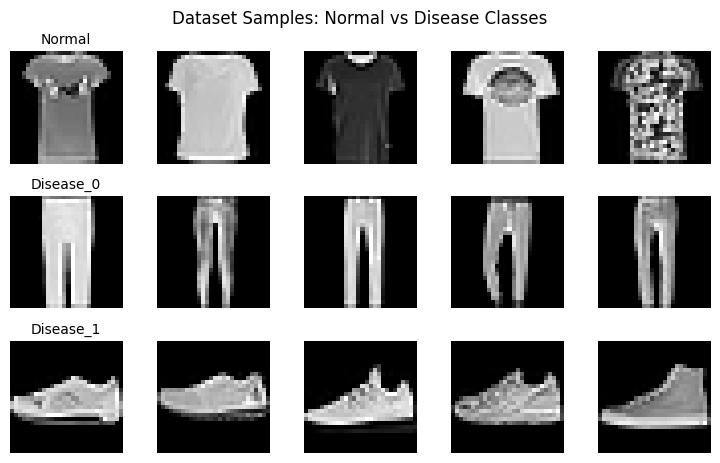

In [4]:
# Visualize samples from each class
def show_samples(loader, class_names, n_per_class=5):
    """Display sample images from each class."""
    samples = {i: [] for i in range(len(class_names))}
    
    for imgs, labels in loader:
        for img, label in zip(imgs, labels):
            if len(samples[label.item()]) < n_per_class:
                samples[label.item()].append(img)
        if all(len(s) >= n_per_class for s in samples.values()):
            break
    
    fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(n_per_class * 1.5, len(class_names) * 1.5))
    for i, name in enumerate(class_names):
        for j, img in enumerate(samples[i][:n_per_class]):
            ax = axes[i, j] if len(class_names) > 1 else axes[j]
            ax.imshow(img.squeeze().numpy() * 0.5 + 0.5, cmap='gray')
            ax.axis('off')
            if j == 0:
                ax.set_title(name, fontsize=10)
    plt.tight_layout()
    plt.suptitle('Dataset Samples: Normal vs Disease Classes', y=1.02)
    plt.show()

show_samples(train_loader, class_names)

---
## 3. Model Architecture

### Architecture Overview

The Mini-SepVAE mimics the real architecture with:
- **Shared Encoder** → extracts features from input
- **Common Head** → outputs μ_c, σ_c for anatomical latent z_c
- **Disease Heads** → outputs μ_d, σ_d for each disease latent z_d
- **Decoder** → reconstructs from concatenated [z_c, z_d_active]

```
Input Image
     │
     ▼
┌─────────────┐
│   Encoder   │
└──────┬──────┘
       │ features
       ├──────────────┬──────────────┐
       ▼              ▼              ▼
┌─────────────┐ ┌─────────────┐ ┌─────────────┐
│ Common Head │ │ Disease_1   │ │ Disease_2   │
│  (μ_c, σ_c) │ │ (μ_d1,σ_d1) │ │ (μ_d2,σ_d2) │
└──────┬──────┘ └──────┬──────┘ └──────┬──────┘
       │               │               │
       ▼               ▼               ▼
      z_c            z_d1            z_d2
       │               │               │
       └───────┬───────┴───────────────┘
               │ (route based on label)
               ▼
        ┌─────────────┐
        │   Decoder   │
        └──────┬──────┘
               │
               ▼
         Reconstruction
```

In [5]:
class Encoder(nn.Module):
    """Shared encoder backbone (analogous to frozen CheSS in real SepVAE)."""
    
    def __init__(self, img_channels: int, hidden_dim: int):
        super().__init__()
        # Simple CNN encoder
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels, 32, 3, stride=2, padding=1),  # 28→14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # 14→7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # 7→4
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(128 * 4 * 4, hidden_dim)
        
    def forward(self, x):
        h = self.conv(x)
        h = self.flatten(h)
        return self.fc(h)


class LatentHead(nn.Module):
    """Latent head that outputs mean and log-variance for reparameterization."""
    
    def __init__(self, hidden_dim: int, z_dim: int):
        super().__init__()
        self.fc_mu = nn.Linear(hidden_dim, z_dim)
        self.fc_logvar = nn.Linear(hidden_dim, z_dim)
        
    def forward(self, h):
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """Reparameterization trick: z = μ + σ * ε, where ε ~ N(0, I)."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps


class Decoder(nn.Module):
    """Decoder that reconstructs from combined latent codes."""
    
    def __init__(self, z_dim_total: int, img_channels: int, hidden_dim: int):
        super().__init__()
        self.fc = nn.Linear(z_dim_total, 128 * 4 * 4)
        self.unflatten = nn.Unflatten(1, (128, 4, 4))
        
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=0),  # 4→7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 7→14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32, img_channels, 3, stride=2, padding=1, output_padding=1),  # 14→28
            nn.Tanh()  # Output in [-1, 1]
        )
        
    def forward(self, z):
        h = self.fc(z)
        h = self.unflatten(h)
        return self.deconv(h)

In [6]:
class MIDiscriminator(nn.Module):
    """Discriminator for Mutual Information estimation.
    
    Learns to distinguish (z_c, z_d) pairs from:
    - Joint distribution: z_c and z_d from same image
    - Marginal distribution: z_c and z_d from different images (shuffled)
    
    If D cannot distinguish joint from marginal → z_c and z_d are independent.
    """
    
    def __init__(self, z_dim_common: int, z_dim_disease: int, hidden_dim: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim_common + z_dim_disease, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
        
    def forward(self, z_common, z_disease):
        """Predict probability that (z_c, z_d) come from joint distribution."""
        z_cat = torch.cat([z_common, z_disease], dim=1)
        return self.net(z_cat)


class PatchDiscriminator(nn.Module):
    """Simple PatchGAN discriminator for adversarial training (optional)."""
    
    def __init__(self, img_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, 32, 4, stride=2, padding=1),  # 28→14
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 14→7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 1, 3, stride=1, padding=1),  # 7→7 (patch output)
            nn.Sigmoid()
        )
        
    def forward(self, x):
        return self.net(x)

In [7]:
class MiniSepVAE(nn.Module):
    """Mini Separable VAE with common + disease-specific latent heads.
    
    Architecture mirrors the real Multi-head SepVAE:
    - z_common: captures class-invariant features (anatomy)
    - z_disease_i: captures disease-specific features (salient)
    
    The nulling mechanism ensures disease heads output N(0, σ²_inactive) for normal samples.
    """
    
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        
        # Shared encoder
        self.encoder = Encoder(cfg.img_channels, cfg.hidden_dim)
        
        # Latent heads
        self.common_head = LatentHead(cfg.hidden_dim, cfg.z_dim_common)
        self.disease_heads = nn.ModuleList([
            LatentHead(cfg.hidden_dim, cfg.z_dim_disease)
            for _ in range(cfg.num_diseases)
        ])
        
        # Decoder
        # Total z_dim = common + one disease head (we route based on label)
        z_dim_total = cfg.z_dim_common + cfg.z_dim_disease
        self.decoder = Decoder(z_dim_total, cfg.img_channels, cfg.hidden_dim)
        
    def encode(self, x, labels):
        """Encode images into common and disease-specific latents.
        
        Returns:
            z_common: Common latent (always active)
            z_disease: Active disease latent (based on label routing)
            encoding_info: Dict with mu, logvar for each head (for loss computation)
        """
        h = self.encoder(x)
        batch_size = x.size(0)
        
        # Common head - always active
        mu_c, logvar_c = self.common_head(h)
        z_c = self.common_head.reparameterize(mu_c, logvar_c)
        
        # Disease heads - routed by label
        # For normal samples (label=0): use zeros (will be penalized by nulling loss)
        # For disease samples (label=i): use disease head i-1
        
        z_d = torch.zeros(batch_size, self.cfg.z_dim_disease, device=x.device)
        mu_d_list = []
        logvar_d_list = []
        
        for i, head in enumerate(self.disease_heads):
            mu_d, logvar_d = head(h)
            mu_d_list.append(mu_d)
            logvar_d_list.append(logvar_d)
            
            # Route: disease i+1 uses head i
            mask = (labels == (i + 1)).float().unsqueeze(1)
            z_d_i = head.reparameterize(mu_d, logvar_d)
            z_d = z_d + mask * z_d_i
        
        encoding_info = {
            'mu_c': mu_c,
            'logvar_c': logvar_c,
            'mu_d_list': mu_d_list,
            'logvar_d_list': logvar_d_list,
            'h': h  # For potential perceptual loss
        }
        
        return z_c, z_d, encoding_info
    
    def decode(self, z_c, z_d):
        """Decode from combined latent codes."""
        z = torch.cat([z_c, z_d], dim=1)
        return self.decoder(z)
    
    def forward(self, x, labels):
        """Full forward pass: encode → decode."""
        z_c, z_d, info = self.encode(x, labels)
        x_recon = self.decode(z_c, z_d)
        return x_recon, z_c, z_d, info

# Create model
model = MiniSepVAE(cfg).to(DEVICE)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 778,049


---
## 4. Loss Functions

Each loss term from the diagnostic manual is implemented below with:
1. **Mathematical expression**
2. **Code implementation**
3. **Gradient flow documentation**

### 4.1 Reconstruction Loss (MSE)

**Mathematical Expression:**
$$L_{rec} = \frac{1}{N} \sum_{i} ||x_i - \hat{x}_i||^2_2$$

**Variables:**
- $x$ = original image (`x` tensor)
- $\hat{x}$ = reconstruction (`x_recon` tensor)
- $N$ = number of pixels

**Gradient Flow:**
- Affects: Encoder → Common Head → Decoder
- Affects: Encoder → Disease Heads → Decoder (for diseased samples)

In [8]:
def reconstruction_loss(x: torch.Tensor, x_recon: torch.Tensor) -> torch.Tensor:
    """MSE reconstruction loss.
    
    Args:
        x: Original images [B, C, H, W]
        x_recon: Reconstructed images [B, C, H, W]
    
    Returns:
        Scalar MSE loss
    """
    return F.mse_loss(x_recon, x, reduction='mean')

### 4.2 KL Divergence Loss

**Mathematical Expression (per head):**
$$L_{KL} = \frac{1}{2} \sum_j \left( \mu_j^2 + \sigma_j^2 - \log(\sigma_j^2) - 1 \right)$$

With **free-bits** (per-dimension floor):
$$L_{KL,effective} = \max(0, L_{KL} - \lambda_{free})$$

With **KL warmup** (annealing factor):
$$\beta(t) = \min(1, t / T_{warmup})$$

**Variables:**
- $\mu$ = latent mean (`mu` tensor)
- $\sigma^2$ = latent variance (`logvar.exp()` tensor)
- $\lambda_{free}$ = free-bits threshold (`cfg.free_bits`)

**Gradient Flow:**
- Affects: Encoder → Head(s) that produce μ, log(σ²)

In [9]:
def kl_divergence(
    mu: torch.Tensor, 
    logvar: torch.Tensor, 
    free_bits: float = 0.0
) -> Tuple[torch.Tensor, torch.Tensor]:
    """KL divergence KL(q(z|x) || N(0, I)) with optional free-bits.
    
    Args:
        mu: Latent mean [B, D]
        logvar: Log variance [B, D]
        free_bits: Minimum KL per dimension (prevents posterior collapse)
    
    Returns:
        kl_loss: Scalar KL loss (with free-bits applied)
        kl_raw: Scalar KL loss (without free-bits, for monitoring)
    """
    # KL per dimension: 0.5 * (μ² + σ² - log(σ²) - 1)
    kl_per_dim = 0.5 * (mu.pow(2) + logvar.exp() - logvar - 1)
    
    # Sum over latent dimensions, mean over batch
    kl_raw = kl_per_dim.sum(dim=1).mean()
    
    # Apply free-bits per dimension
    if free_bits > 0:
        kl_per_dim = torch.clamp(kl_per_dim - free_bits, min=0)
    
    kl_loss = kl_per_dim.sum(dim=1).mean()
    
    return kl_loss, kl_raw


def get_kl_weight(epoch: int, cfg: Config) -> float:
    """KL annealing warmup schedule.
    
    β(t) = min(1, epoch / warmup_epochs)
    """
    if cfg.kl_warmup_epochs <= 0:
        return 1.0
    return min(1.0, epoch / cfg.kl_warmup_epochs)

### 4.3 Nulling Loss

**Mathematical Expression:**
$$L_{null} = \frac{1}{|D|} \sum_{d \in D} KL\left( q(z_d | x_{normal}) \| \mathcal{N}(0, \sigma^2_{inactive} I) \right)$$

Expanding:
$$L_{null} = \frac{1}{2|D|} \sum_d \sum_j \left[ \frac{\mu_{d,j}^2}{\sigma^2_{inactive}} + \frac{\sigma_{d,j}^2}{\sigma^2_{inactive}} - \log\left(\frac{\sigma_{d,j}^2}{\sigma^2_{inactive}}\right) - 1 \right]$$

**Purpose:** Forces disease heads to output N(0, σ²_inactive) for normal samples.

**Variables:**
- $x_{normal}$ = samples with label 0 (`labels == 0` mask)
- $\sigma_{inactive}$ = prior std for inactive heads (`cfg.sigma_inactive`)
- $D$ = set of disease heads

**Gradient Flow:**
- Affects: Encoder → Disease Heads (for normal samples only)

In [10]:
def nulling_loss(
    mu_d_list: List[torch.Tensor],
    logvar_d_list: List[torch.Tensor],
    labels: torch.Tensor,
    sigma_inactive: float = 1.0
) -> torch.Tensor:
    """Nulling loss: penalize disease heads for normal samples.
    
    For samples labeled as normal (class 0), all disease heads should
    output distributions close to N(0, σ²_inactive).
    
    Args:
        mu_d_list: List of disease head means [B, D_disease] each
        logvar_d_list: List of disease head log-variances
        labels: Class labels [B]
        sigma_inactive: Prior std for inactive heads
    
    Returns:
        Scalar nulling loss
    """
    # Identify normal samples
    normal_mask = (labels == 0).float()
    n_normal = normal_mask.sum()
    
    if n_normal == 0:
        return torch.tensor(0.0, device=labels.device)
    
    var_inactive = sigma_inactive ** 2
    total_null_loss = 0.0
    
    for mu_d, logvar_d in zip(mu_d_list, logvar_d_list):
        # KL(N(μ, σ²) || N(0, σ²_inactive))
        var_d = logvar_d.exp()
        
        kl_per_dim = 0.5 * (
            mu_d.pow(2) / var_inactive +
            var_d / var_inactive -
            torch.log(var_d / var_inactive) - 1
        )
        
        # Sum over dimensions, select only normal samples
        kl_per_sample = kl_per_dim.sum(dim=1)
        null_loss = (kl_per_sample * normal_mask).sum() / n_normal
        total_null_loss = total_null_loss + null_loss
    
    # Average over disease heads
    return total_null_loss / len(mu_d_list)

### 4.4 Mutual Information (MI) Penalty

**Discriminator Objective (maximize):**
$$L_{MI,disc} = \mathbb{E}_{(z_c, z_d) \sim joint}[\log D(z_c, z_d)] + \mathbb{E}_{(z_c, z_d') \sim marginal}[\log(1 - D(z_c, z_d'))]$$

**Encoder MI Penalty (minimize):**
$$L_{MI,penalty} = -\mathbb{E}_{(z_c, z_d) \sim joint}[\log(1 - D(z_c, z_d))]$$

**Purpose:** Ensure z_c and z_d are statistically independent.

**Variables:**
- $D(z_c, z_d)$ = MI discriminator output (`mi_disc(z_c, z_d)`)
- joint = (z_c, z_d) from same image
- marginal = (z_c, z_d') where z_d' is shuffled from different images

**Gradient Flow:**
- Discriminator loss → MI Discriminator parameters
- Encoder MI penalty → Encoder + Common/Disease Heads

In [11]:
def mi_discriminator_loss(
    mi_disc: nn.Module,
    z_c: torch.Tensor,
    z_d: torch.Tensor
) -> torch.Tensor:
    """MI discriminator loss: learn to distinguish joint from marginal.
    
    Args:
        mi_disc: MI discriminator network
        z_c: Common latents [B, D_common]
        z_d: Disease latents [B, D_disease]
    
    Returns:
        Discriminator loss (to minimize)
    """
    batch_size = z_c.size(0)
    
    # Joint pairs: (z_c, z_d) from same sample
    joint_pred = mi_disc(z_c, z_d)
    joint_target = torch.ones_like(joint_pred)
    
    # Marginal pairs: shuffle z_d to break correlation
    shuffle_idx = torch.randperm(batch_size, device=z_c.device)
    z_d_shuffled = z_d[shuffle_idx]
    marginal_pred = mi_disc(z_c, z_d_shuffled)
    marginal_target = torch.zeros_like(marginal_pred)
    
    # Binary cross-entropy loss
    loss_joint = F.binary_cross_entropy(joint_pred, joint_target)
    loss_marginal = F.binary_cross_entropy(marginal_pred, marginal_target)
    
    return loss_joint + loss_marginal


def mi_encoder_penalty(
    mi_disc: nn.Module,
    z_c: torch.Tensor,
    z_d: torch.Tensor
) -> torch.Tensor:
    """MI penalty for encoder: make z_c and z_d indistinguishable from marginal.
    
    The encoder wants D(z_c, z_d) → 0.5 (can't distinguish joint from marginal),
    which means z_c and z_d are independent.
    
    Args:
        mi_disc: MI discriminator network
        z_c: Common latents [B, D_common]
        z_d: Disease latents [B, D_disease]
    
    Returns:
        MI penalty (to minimize)
    """
    # Encoder wants discriminator to think joint pairs are marginal
    joint_pred = mi_disc(z_c, z_d)
    
    # Penalty: -log(1 - D) encourages D → 0 for joint pairs
    # Equivalent to fooling discriminator
    return -torch.log(1 - joint_pred + 1e-8).mean()

### 4.5 Adversarial Loss (Optional)

**Generator Loss (Least-Squares):**
$$L_{adv,G} = \mathbb{E}_{\hat{x}}[(D(\hat{x}) - 1)^2]$$

**Discriminator Loss:**
$$L_{adv,D} = \mathbb{E}_x[(D(x) - 1)^2] + \mathbb{E}_{\hat{x}}[D(\hat{x})^2]$$

**Gradient Flow:**
- Discriminator loss → Patch Discriminator parameters
- Generator loss → Decoder parameters

In [12]:
def adversarial_discriminator_loss(
    patch_disc: nn.Module,
    x_real: torch.Tensor,
    x_fake: torch.Tensor
) -> torch.Tensor:
    """PatchGAN discriminator loss (LSGAN formulation)."""
    pred_real = patch_disc(x_real)
    pred_fake = patch_disc(x_fake.detach())
    
    loss_real = F.mse_loss(pred_real, torch.ones_like(pred_real))
    loss_fake = F.mse_loss(pred_fake, torch.zeros_like(pred_fake))
    
    return (loss_real + loss_fake) / 2


def adversarial_generator_loss(
    patch_disc: nn.Module,
    x_fake: torch.Tensor
) -> torch.Tensor:
    """Generator adversarial loss: fool the discriminator."""
    pred_fake = patch_disc(x_fake)
    return F.mse_loss(pred_fake, torch.ones_like(pred_fake))

### 4.6 Total Loss

**Total Loss:**
$$L_{total} = \lambda_{rec} L_{rec} + \beta(t) \cdot (\lambda_{kl,c} L_{KL,c} + \lambda_{kl,d} L_{KL,d}) + \lambda_{null} L_{null} + \lambda_{mi} L_{MI} + \lambda_{adv} L_{adv,G}$$

In [13]:
def compute_all_losses(
    model: MiniSepVAE,
    mi_disc: MIDiscriminator,
    patch_disc: Optional[PatchDiscriminator],
    x: torch.Tensor,
    labels: torch.Tensor,
    cfg: Config,
    epoch: int
) -> Dict[str, torch.Tensor]:
    """Compute all loss terms for a batch.
    
    Returns dict with all individual losses and total.
    """
    # Forward pass
    x_recon, z_c, z_d, info = model(x, labels)
    
    losses = {}
    
    # 1. Reconstruction loss
    losses['rec'] = reconstruction_loss(x, x_recon)
    
    # 2. KL divergence (common)
    kl_c, kl_c_raw = kl_divergence(info['mu_c'], info['logvar_c'], cfg.free_bits)
    losses['kl_common'] = kl_c
    losses['kl_common_raw'] = kl_c_raw.detach()
    
    # 3. KL divergence (disease) - only for diseased samples
    kl_d_total = torch.tensor(0.0, device=x.device)
    kl_d_raw_total = torch.tensor(0.0, device=x.device)
    
    for i, (mu_d, logvar_d) in enumerate(zip(info['mu_d_list'], info['logvar_d_list'])):
        # Only compute KL for samples that use this disease head
        disease_mask = (labels == (i + 1)).float()
        n_disease = disease_mask.sum()
        
        if n_disease > 0:
            kl_d, kl_d_raw = kl_divergence(mu_d, logvar_d, cfg.free_bits)
            # Weight by proportion of diseased samples
            weight = n_disease / x.size(0)
            kl_d_total = kl_d_total + weight * kl_d
            kl_d_raw_total = kl_d_raw_total + weight * kl_d_raw.detach()
    
    losses['kl_disease'] = kl_d_total
    losses['kl_disease_raw'] = kl_d_raw_total
    
    # 4. Nulling loss
    losses['nulling'] = nulling_loss(
        info['mu_d_list'], info['logvar_d_list'], 
        labels, cfg.sigma_inactive
    )
    
    # 5. MI penalty
    losses['mi_penalty'] = mi_encoder_penalty(mi_disc, z_c, z_d)
    
    # 6. Adversarial loss (optional, after warmup)
    if patch_disc is not None and epoch >= cfg.disc_start_epoch and cfg.weight_adversarial > 0:
        losses['adversarial'] = adversarial_generator_loss(patch_disc, x_recon)
    else:
        losses['adversarial'] = torch.tensor(0.0, device=x.device)
    
    # KL warmup factor
    beta = get_kl_weight(epoch, cfg)
    losses['beta'] = torch.tensor(beta)
    
    # Total loss
    losses['total'] = (
        cfg.weight_rec * losses['rec'] +
        beta * cfg.weight_kl_common * losses['kl_common'] +
        beta * cfg.weight_kl_disease * losses['kl_disease'] +
        cfg.weight_null * losses['nulling'] +
        cfg.weight_mi * losses['mi_penalty'] +
        cfg.weight_adversarial * losses['adversarial']
    )
    
    # Store latents for diagnostics
    losses['z_c'] = z_c.detach()
    losses['z_d'] = z_d.detach()
    losses['x_recon'] = x_recon.detach()
    
    return losses

---
## 5. Training Loop

In [14]:
class TrainingHistory:
    """Track training metrics over time."""
    
    def __init__(self):
        self.losses = defaultdict(list)  # loss_name -> [values per step]
        self.epoch_losses = defaultdict(list)  # loss_name -> [values per epoch]
        self.grad_norms = defaultdict(list)  # module_name -> [norms per step]
        self.latents = []  # [(z_c, z_d, labels)] per epoch
        
    def log_step(self, losses: Dict[str, torch.Tensor], grad_norms: Dict[str, float] = None):
        """Log metrics for a training step."""
        for name, value in losses.items():
            if isinstance(value, torch.Tensor) and value.dim() == 0:
                self.losses[name].append(value.item())
        
        if grad_norms:
            for name, norm in grad_norms.items():
                self.grad_norms[name].append(norm)
    
    def log_epoch(self):
        """Compute epoch averages."""
        for name, values in self.losses.items():
            if values:
                recent = values[-len(values):]  # All steps this epoch
                self.epoch_losses[name].append(np.mean(recent))
    
    def log_latents(self, z_c, z_d, labels):
        """Store latent codes for visualization."""
        self.latents.append((z_c.cpu(), z_d.cpu(), labels.cpu()))


def compute_grad_norms(model: nn.Module) -> Dict[str, float]:
    """Compute gradient norms per module."""
    norms = {}
    
    # Encoder
    enc_params = list(model.encoder.parameters())
    if enc_params and enc_params[0].grad is not None:
        norms['encoder'] = sum(p.grad.norm().item() ** 2 for p in enc_params if p.grad is not None) ** 0.5
    
    # Decoder
    dec_params = list(model.decoder.parameters())
    if dec_params and dec_params[0].grad is not None:
        norms['decoder'] = sum(p.grad.norm().item() ** 2 for p in dec_params if p.grad is not None) ** 0.5
    
    # Common head
    head_params = list(model.common_head.parameters())
    if head_params and head_params[0].grad is not None:
        norms['common_head'] = sum(p.grad.norm().item() ** 2 for p in head_params if p.grad is not None) ** 0.5
    
    # Disease heads (average)
    disease_norm = 0.0
    for head in model.disease_heads:
        head_params = list(head.parameters())
        if head_params and head_params[0].grad is not None:
            disease_norm += sum(p.grad.norm().item() ** 2 for p in head_params if p.grad is not None) ** 0.5
    norms['disease_heads'] = disease_norm / len(model.disease_heads)
    
    return norms

In [15]:
def train_epoch(
    model: MiniSepVAE,
    mi_disc: MIDiscriminator,
    patch_disc: Optional[PatchDiscriminator],
    train_loader: DataLoader,
    opt_vae: optim.Optimizer,
    opt_mi_disc: optim.Optimizer,
    opt_patch_disc: Optional[optim.Optimizer],
    cfg: Config,
    epoch: int,
    history: TrainingHistory
) -> Dict[str, float]:
    """Train for one epoch."""
    model.train()
    mi_disc.train()
    if patch_disc:
        patch_disc.train()
    
    epoch_z_c, epoch_z_d, epoch_labels = [], [], []
    
    for step, (x, labels) in enumerate(train_loader):
        x, labels = x.to(DEVICE), labels.to(DEVICE)
        
        # === Update MI Discriminator ===
        opt_mi_disc.zero_grad()
        with torch.no_grad():
            _, z_c, z_d, _ = model(x, labels)
        mi_disc_loss = mi_discriminator_loss(mi_disc, z_c, z_d)
        mi_disc_loss.backward()
        opt_mi_disc.step()
        
        # === Update Patch Discriminator (if active) ===
        if patch_disc and epoch >= cfg.disc_start_epoch and cfg.weight_adversarial > 0:
            opt_patch_disc.zero_grad()
            with torch.no_grad():
                x_recon, _, _, _ = model(x, labels)
            patch_disc_loss = adversarial_discriminator_loss(patch_disc, x, x_recon)
            patch_disc_loss.backward()
            opt_patch_disc.step()
        else:
            patch_disc_loss = torch.tensor(0.0)
        
        # === Update VAE (encoder + decoder + heads) ===
        opt_vae.zero_grad()
        losses = compute_all_losses(model, mi_disc, patch_disc, x, labels, cfg, epoch)
        losses['total'].backward()
        
        # Compute gradient norms before step
        grad_norms = compute_grad_norms(model)
        
        opt_vae.step()
        
        # Log
        losses['mi_disc'] = mi_disc_loss.detach()
        losses['patch_disc'] = patch_disc_loss.detach() if isinstance(patch_disc_loss, torch.Tensor) else torch.tensor(patch_disc_loss)
        history.log_step(losses, grad_norms)
        
        # Collect latents
        epoch_z_c.append(losses['z_c'].cpu())
        epoch_z_d.append(losses['z_d'].cpu())
        epoch_labels.append(labels.cpu())
        
        # Progress logging
        if (step + 1) % cfg.log_every == 0:
            print(f"  Step {step+1}: rec={losses['rec'].item():.4f}, "
                  f"kl_c={losses['kl_common_raw'].item():.2f}, "
                  f"null={losses['nulling'].item():.4f}, "
                  f"mi={losses['mi_penalty'].item():.4f}")
    
    # Store epoch latents
    history.log_latents(
        torch.cat(epoch_z_c),
        torch.cat(epoch_z_d),
        torch.cat(epoch_labels)
    )
    history.log_epoch()
    
    return {k: v[-1] for k, v in history.epoch_losses.items()}

In [16]:
def train(
    cfg: Config,
    train_loader: DataLoader,
    test_loader: DataLoader,
    verbose: bool = True
) -> Tuple[MiniSepVAE, MIDiscriminator, TrainingHistory]:
    """Full training loop."""
    # Reset seed for reproducibility
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    
    # Create models
    model = MiniSepVAE(cfg).to(DEVICE)
    mi_disc = MIDiscriminator(cfg.z_dim_common, cfg.z_dim_disease).to(DEVICE)
    
    patch_disc = None
    opt_patch_disc = None
    if cfg.weight_adversarial > 0:
        patch_disc = PatchDiscriminator(cfg.img_channels).to(DEVICE)
        opt_patch_disc = optim.Adam(patch_disc.parameters(), lr=cfg.lr_mi_disc)
    
    # Optimizers
    opt_vae = optim.Adam(model.parameters(), lr=cfg.lr_vae)
    opt_mi_disc = optim.Adam(mi_disc.parameters(), lr=cfg.lr_mi_disc)
    
    history = TrainingHistory()
    
    for epoch in range(1, cfg.epochs + 1):
        if verbose:
            beta = get_kl_weight(epoch, cfg)
            print(f"\nEpoch {epoch}/{cfg.epochs} (β={beta:.2f})")
        
        epoch_losses = train_epoch(
            model, mi_disc, patch_disc, train_loader,
            opt_vae, opt_mi_disc, opt_patch_disc,
            cfg, epoch, history
        )
        
        if verbose:
            print(f"  Epoch avg: rec={epoch_losses.get('rec', 0):.4f}, "
                  f"kl_total={epoch_losses.get('kl_common_raw', 0) + epoch_losses.get('kl_disease_raw', 0):.2f}, "
                  f"null={epoch_losses.get('nulling', 0):.4f}, "
                  f"mi={epoch_losses.get('mi_penalty', 0):.4f}")
    
    return model, mi_disc, history

---
## 6. Diagnostics & Visualization

In [17]:
def plot_loss_curves(history: TrainingHistory, title: str = "Training Losses"):
    """Plot all loss curves over training."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    # Reconstruction
    ax = axes[0, 0]
    if 'rec' in history.epoch_losses:
        ax.plot(history.epoch_losses['rec'], 'b-', label='Reconstruction')
        ax.set_ylabel('MSE')
        ax.set_title('Reconstruction Loss')
        ax.axhline(y=0.05, color='g', linestyle='--', alpha=0.5, label='Good threshold')
        ax.legend()
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    
    # KL Divergence
    ax = axes[0, 1]
    if 'kl_common_raw' in history.epoch_losses:
        ax.plot(history.epoch_losses['kl_common_raw'], 'r-', label='KL Common')
    if 'kl_disease_raw' in history.epoch_losses:
        ax.plot(history.epoch_losses['kl_disease_raw'], 'orange', label='KL Disease')
    ax.axhline(y=5, color='r', linestyle='--', alpha=0.5, label='Collapse threshold')
    ax.axhline(y=200, color='purple', linestyle='--', alpha=0.5, label='Over-reg threshold')
    ax.set_ylabel('KL (nats)')
    ax.set_xlabel('Epoch')
    ax.set_title('KL Divergence')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Nulling
    ax = axes[0, 2]
    if 'nulling' in history.epoch_losses:
        ax.plot(history.epoch_losses['nulling'], 'g-', label='Nulling')
        ax.axhline(y=0.05, color='g', linestyle='--', alpha=0.5, label='Good threshold')
        ax.axhline(y=0.3, color='r', linestyle='--', alpha=0.5, label='Alert threshold')
    ax.set_ylabel('Nulling Loss')
    ax.set_xlabel('Epoch')
    ax.set_title('Nulling Loss (Disease→Normal)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # MI Penalty
    ax = axes[1, 0]
    if 'mi_penalty' in history.epoch_losses:
        ax.plot(history.epoch_losses['mi_penalty'], 'm-', label='MI Encoder')
    if 'mi_disc' in history.epoch_losses:
        ax.plot(history.epoch_losses['mi_disc'], 'c-', label='MI Disc')
    ax.axhline(y=0.3, color='g', linestyle='--', alpha=0.5, label='Equilibrium')
    ax.axhline(y=0.8, color='g', linestyle='--', alpha=0.5)
    ax.set_ylabel('MI Loss')
    ax.set_xlabel('Epoch')
    ax.set_title('Mutual Information Dynamics')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Total Loss
    ax = axes[1, 1]
    if 'total' in history.epoch_losses:
        ax.plot(history.epoch_losses['total'], 'k-', linewidth=2, label='Total')
    ax.set_ylabel('Total Loss')
    ax.set_xlabel('Epoch')
    ax.set_title('Total Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Gradient Norms
    ax = axes[1, 2]
    if history.grad_norms:
        for name, norms in history.grad_norms.items():
            # Subsample for clarity
            ax.plot(norms[::10], label=name, alpha=0.7)
    ax.set_ylabel('Gradient Norm')
    ax.set_xlabel('Step (×10)')
    ax.set_title('Gradient Norms')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_reconstructions(
    model: MiniSepVAE,
    test_loader: DataLoader,
    class_names: List[str],
    n_per_class: int = 4
):
    """Show original vs reconstructed images per class."""
    model.eval()
    
    samples = {i: {'orig': [], 'recon': []} for i in range(len(class_names))}
    
    with torch.no_grad():
        for x, labels in test_loader:
            x, labels = x.to(DEVICE), labels.to(DEVICE)
            x_recon, _, _, _ = model(x, labels)
            
            for i in range(len(x)):
                label = labels[i].item()
                if len(samples[label]['orig']) < n_per_class:
                    samples[label]['orig'].append(x[i].cpu())
                    samples[label]['recon'].append(x_recon[i].cpu())
            
            if all(len(s['orig']) >= n_per_class for s in samples.values()):
                break
    
    n_classes = len(class_names)
    fig, axes = plt.subplots(n_classes * 2, n_per_class, figsize=(n_per_class * 2, n_classes * 3))
    
    for c, name in enumerate(class_names):
        for j in range(n_per_class):
            # Original
            ax = axes[c * 2, j]
            img = samples[c]['orig'][j].squeeze().numpy() * 0.5 + 0.5
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if j == 0:
                ax.set_ylabel(f'{name}\nOrig', fontsize=10)
            
            # Reconstruction
            ax = axes[c * 2 + 1, j]
            img = samples[c]['recon'][j].squeeze().numpy() * 0.5 + 0.5
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
            if j == 0:
                ax.set_ylabel('Recon', fontsize=10)
    
    plt.suptitle('Reconstruction Quality: Original vs Decoded', fontsize=14)
    plt.tight_layout()
    plt.show()

In [19]:
def plot_latent_space(
    history: TrainingHistory,
    class_names: List[str],
    epoch: int = -1,
    method: str = 'pca'
):
    """Visualize latent space via PCA or t-SNE.
    
    Shows:
    - z_common: Should NOT cluster by disease (captures anatomy only)
    - z_disease: SHOULD cluster by disease (captures salient features)
    """
    if not history.latents:
        print("No latents recorded")
        return
    
    z_c, z_d, labels = history.latents[epoch]
    z_c = z_c.numpy()
    z_d = z_d.numpy()
    labels = labels.numpy()
    
    # Subsample for speed
    n_samples = min(1000, len(labels))
    idx = np.random.choice(len(labels), n_samples, replace=False)
    z_c, z_d, labels = z_c[idx], z_d[idx], labels[idx]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    colors = ['blue', 'red', 'green', 'orange', 'purple'][:len(class_names)]
    
    for ax_idx, (z, title) in enumerate([(z_c, 'z_common (Anatomy)'), (z_d, 'z_disease (Salient)')]):
        ax = axes[ax_idx]
        
        if method == 'pca':
            reducer = PCA(n_components=2)
            z_2d = reducer.fit_transform(z)
        else:
            reducer = TSNE(n_components=2, perplexity=30, random_state=SEED)
            z_2d = reducer.fit_transform(z)
        
        for c, name in enumerate(class_names):
            mask = labels == c
            ax.scatter(z_2d[mask, 0], z_2d[mask, 1], c=colors[c], 
                      label=name, alpha=0.6, s=20)
        
        ax.set_title(title)
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Compute silhouette score
        if len(np.unique(labels)) > 1:
            sil_score = silhouette_score(z, labels)
            ax.set_title(f"{title}\nSilhouette: {sil_score:.3f}")
    
    plt.suptitle(f'Latent Space Visualization ({method.upper()}) - Epoch {epoch if epoch >= 0 else "Final"}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Print interpretation
    z_c_sil = silhouette_score(z_c, labels) if len(np.unique(labels)) > 1 else 0
    z_d_sil = silhouette_score(z_d, labels) if len(np.unique(labels)) > 1 else 0
    
    print("\n=== Latent Space Diagnostic ===")
    print(f"z_common silhouette: {z_c_sil:.3f}")
    if z_c_sil < 0.1:
        print("  ✓ GOOD: No disease clustering in common space (anatomy only)")
    elif z_c_sil > 0.3:
        print("  ✗ WARNING: Disease information leaking into common space!")
    else:
        print("  ~ MODERATE: Some clustering, monitor MI penalty")
    
    print(f"z_disease silhouette: {z_d_sil:.3f}")
    if z_d_sil > 0.5:
        print("  ✓ GOOD: Clear disease separation in salient space")
    elif z_d_sil < 0.2:
        print("  ✗ WARNING: Poor disease separation - check nulling/routing")
    else:
        print("  ~ MODERATE: Emerging structure, may improve with more training")

In [20]:
def interpolation_test(
    model: MiniSepVAE,
    test_loader: DataLoader,
    n_steps: int = 8
):
    """Test latent interpolation smoothness.
    
    From the manual: If interpolation produces blurry midpoints,
    the manifold has 'voids' - regions with no training support.
    """
    model.eval()
    
    # Get one sample from each class
    samples = {}
    with torch.no_grad():
        for x, labels in test_loader:
            for i in range(len(x)):
                label = labels[i].item()
                if label not in samples:
                    samples[label] = x[i:i+1].to(DEVICE)
            if len(samples) == 3:
                break
    
    # Encode all samples
    latents = {}
    with torch.no_grad():
        for label, x in samples.items():
            lbl = torch.tensor([label]).to(DEVICE)
            z_c, z_d, _ = model.encode(x, lbl)
            latents[label] = (z_c, z_d)
    
    # Interpolate between classes
    fig, axes = plt.subplots(3, n_steps, figsize=(n_steps * 1.5, 5))
    
    pairs = [(0, 1), (0, 2), (1, 2)]  # Normal↔Disease1, Normal↔Disease2, Disease1↔Disease2
    pair_names = ['Normal → Disease_1', 'Normal → Disease_2', 'Disease_1 → Disease_2']
    
    spike_ratios = []
    
    for row, ((start, end), name) in enumerate(zip(pairs, pair_names)):
        z_c_start, z_d_start = latents[start]
        z_c_end, z_d_end = latents[end]
        
        images = []
        for i, t in enumerate(np.linspace(0, 1, n_steps)):
            z_c_interp = (1 - t) * z_c_start + t * z_c_end
            z_d_interp = (1 - t) * z_d_start + t * z_d_end
            
            with torch.no_grad():
                x_interp = model.decode(z_c_interp, z_d_interp)
            
            img = x_interp[0].cpu().squeeze().numpy() * 0.5 + 0.5
            images.append(img)
            
            axes[row, i].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[row, i].axis('off')
            if i == 0:
                axes[row, i].set_ylabel(name, fontsize=9)
        
        # Compute spike ratio (smoothness metric)
        diffs = [np.abs(images[i+1] - images[i]).mean() for i in range(len(images)-1)]
        if np.mean(diffs) > 0:
            spike_ratio = np.max(diffs) / np.mean(diffs)
        else:
            spike_ratio = 1.0
        spike_ratios.append(spike_ratio)
    
    plt.suptitle('Latent Interpolation Test', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Diagnostic
    print("\n=== Interpolation Smoothness Diagnostic ===")
    for name, ratio in zip(pair_names, spike_ratios):
        print(f"{name}: spike ratio = {ratio:.2f}")
        if ratio < 2.0:
            print("  ✓ GOOD: Smooth transition, Euclidean interpolation valid")
        else:
            print("  ✗ WARNING: Spike detected - manifold has voids or curvature!")
            print("            Consider: Increase free_bits, reduce KL, check coverage")

In [21]:
def run_diagnostics(
    model: MiniSepVAE,
    mi_disc: MIDiscriminator,
    history: TrainingHistory,
    test_loader: DataLoader,
    class_names: List[str],
    cfg: Config
):
    """Run full diagnostic suite matching the SepVAE manual."""
    print("="*60)
    print("SEPVAE TRAINING DIAGNOSTICS")
    print("="*60)
    
    # 1. Loss curve analysis
    print("\n[1/5] Loss Curve Analysis")
    plot_loss_curves(history, f"Training Dynamics (cfg: KL={cfg.weight_kl_common}, null={cfg.weight_null}, MI={cfg.weight_mi})")
    
    # Threshold checks from manual
    final_rec = history.epoch_losses.get('rec', [0])[-1]
    final_kl = history.epoch_losses.get('kl_common_raw', [0])[-1] + history.epoch_losses.get('kl_disease_raw', [0])[-1]
    final_null = history.epoch_losses.get('nulling', [0])[-1]
    final_mi = history.epoch_losses.get('mi_penalty', [0])[-1]
    
    print("\n--- Loss Value Assessment ---")
    print(f"Reconstruction: {final_rec:.4f}")
    if final_rec < 0.02:
        print("  ✓ Excellent reconstruction quality")
    elif final_rec < 0.05:
        print("  ~ Acceptable, may need decoder refinement")
    else:
        print("  ✗ Poor - check decoder capacity, KL weight")
    
    print(f"KL Total: {final_kl:.2f}")
    if final_kl < 5:
        print("  ✗ POSTERIOR COLLAPSE! Increase free_bits or reduce KL weight")
    elif final_kl > 200:
        print("  ✗ OVER-REGULARIZED! Reduce KL weight")
    else:
        print("  ✓ Healthy range (10-100)")
    
    print(f"Nulling: {final_null:.4f}")
    if final_null < 0.05:
        print("  ✓ Proper disease head routing for normals")
    elif final_null > 0.3:
        print("  ✗ Nulling failure - disease leaking into normal samples")
    else:
        print("  ~ Moderate, may improve with training")
    
    print(f"MI Penalty: {final_mi:.4f}")
    if 0.3 <= final_mi <= 0.8:
        print("  ✓ MI equilibrium reached")
    elif final_mi < 0.1:
        print("  ✗ MI too low - encoder may be ignoring MI signal")
    else:
        print("  ✗ MI too high - latents may be entangled")
    
    # 2. Reconstructions
    print("\n[2/5] Reconstruction Quality")
    plot_reconstructions(model, test_loader, class_names)
    
    # 3. Latent space
    print("\n[3/5] Latent Space Structure")
    plot_latent_space(history, class_names, epoch=-1, method='pca')
    
    # 4. Interpolation test
    print("\n[4/5] Interpolation Smoothness Test")
    interpolation_test(model, test_loader)
    
    # 5. Summary
    print("\n[5/5] Summary")
    print("="*60)
    
    issues = []
    if final_rec > 0.05:
        issues.append("High reconstruction loss")
    if final_kl < 5:
        issues.append("Posterior collapse")
    if final_kl > 200:
        issues.append("Over-regularization")
    if final_null > 0.3:
        issues.append("Nulling failure")
    if final_mi < 0.1 or final_mi > 1.5:
        issues.append("MI imbalance")
    
    if not issues:
        print("✓ All diagnostics PASS - model is healthy!")
        print("  Ready for downstream tasks (LDM training, etc.)")
    else:
        print(f"✗ Issues detected: {', '.join(issues)}")
        print("  See recommendations above for fixes.")

---
## 7. Experiments

Each experiment demonstrates a specific training dynamic or failure mode from the SepVAE diagnostic manual.

In [22]:
# Experiment configurations
EXPERIMENTS = {
    'healthy': {
        'description': '''HEALTHY TRAINING
        Expected: Good reconstruction, stable KL (10-100), low nulling (<0.05), MI equilibrium (0.3-0.8)
        Settings: Balanced weights, KL warmup, moderate free_bits''',
        'config': {
            'weight_kl_common': 1e-3,
            'weight_kl_disease': 1e-3,
            'weight_null': 1e-2,
            'weight_mi': 1e-3,
            'kl_warmup_epochs': 5,
            'free_bits': 0.5,
            'epochs': 30,
        }
    },
    'posterior_collapse': {
        'description': '''POSTERIOR COLLAPSE
        Expected: KL → 0, reconstructions may still look OK (decoder bypasses latents)
        Cause: KL weight too high, no free_bits protection
        Fix: Enable free_bits, reduce KL weight''',
        'config': {
            'weight_kl_common': 1e-1,  # 100x higher!
            'weight_kl_disease': 1e-1,
            'weight_null': 1e-2,
            'weight_mi': 1e-3,
            'kl_warmup_epochs': 0,  # No warmup
            'free_bits': 0.0,  # No protection
            'epochs': 30,
        }
    },
    'over_regularization': {
        'description': '''OVER-REGULARIZATION (Blurry Reconstructions)
        Expected: KL very high (>200), blurry reconstructions
        Cause: KL weight high but not causing collapse (free_bits active)
        Fix: Reduce KL weight''',
        'config': {
            'weight_kl_common': 5e-2,
            'weight_kl_disease': 5e-2,
            'weight_null': 1e-2,
            'weight_mi': 1e-3,
            'kl_warmup_epochs': 0,
            'free_bits': 2.0,  # High free_bits prevents collapse but causes blur
            'epochs': 30,
        }
    },
    'nulling_failure': {
        'description': '''NULLING FAILURE (Disease Leakage)
        Expected: High nulling loss, disease features visible in normal reconstructions
        Cause: Nulling weight too low
        Fix: Increase weight_null''',
        'config': {
            'weight_kl_common': 1e-3,
            'weight_kl_disease': 1e-3,
            'weight_null': 1e-5,  # Way too low!
            'weight_mi': 1e-3,
            'kl_warmup_epochs': 5,
            'free_bits': 0.5,
            'epochs': 30,
        }
    },
    'mi_too_weak': {
        'description': '''MI TOO WEAK (Entangled Latents)
        Expected: Disease clusters visible in common space (silhouette > 0.3)
        Cause: MI penalty too low, latents share information
        Fix: Increase weight_mi''',
        'config': {
            'weight_kl_common': 1e-3,
            'weight_kl_disease': 1e-3,
            'weight_null': 1e-2,
            'weight_mi': 1e-6,  # Way too low!
            'kl_warmup_epochs': 5,
            'free_bits': 0.5,
            'epochs': 30,
        }
    },
    'mi_too_strong': {
        'description': '''MI TOO STRONG (Over-Separated / Islands)
        Expected: Sparse manifold, interpolation produces blurry midpoints
        Cause: MI penalty too high, forcing extreme separation
        Fix: Reduce weight_mi''',
        'config': {
            'weight_kl_common': 1e-3,
            'weight_kl_disease': 1e-3,
            'weight_null': 1e-2,
            'weight_mi': 1e-1,  # Way too high!
            'kl_warmup_epochs': 5,
            'free_bits': 0.5,
            'epochs': 30,
        }
    },
    'manifold_voids': {
        'description': '''MANIFOLD VOIDS (Isolated Clusters)
        Expected: Good classification separation but interpolation fails
        Cause: Excessive KL without free_bits creates sparse manifold
        Fix: Increase free_bits for better coverage''',
        'config': {
            'weight_kl_common': 2e-2,
            'weight_kl_disease': 2e-2,
            'weight_null': 1e-2,
            'weight_mi': 5e-3,
            'kl_warmup_epochs': 0,
            'free_bits': 0.0,  # No coverage protection
            'epochs': 30,
        }
    },
    'adversarial_instability': {
        'description': '''ADVERSARIAL INSTABILITY
        Expected: Loss spikes when discriminator activates, possible checkerboard
        Cause: Adversarial weight too high, early start
        Fix: Delay disc_start_epoch, reduce weight_adversarial''',
        'config': {
            'weight_kl_common': 1e-3,
            'weight_kl_disease': 1e-3,
            'weight_null': 1e-2,
            'weight_mi': 1e-3,
            'weight_adversarial': 0.5,  # Too high!
            'disc_start_epoch': 3,  # Too early!
            'kl_warmup_epochs': 5,
            'free_bits': 0.5,
            'epochs': 30,
        }
    },
}

In [23]:
def run_experiment(experiment_name: str):
    """Run a specific experiment and display diagnostics."""
    if experiment_name not in EXPERIMENTS:
        print(f"Unknown experiment: {experiment_name}")
        print(f"Available: {list(EXPERIMENTS.keys())}")
        return
    
    exp = EXPERIMENTS[experiment_name]
    print("="*60)
    print(f"EXPERIMENT: {experiment_name.upper()}")
    print("="*60)
    print(exp['description'])
    print("\nConfiguration:")
    for k, v in exp['config'].items():
        print(f"  {k}: {v}")
    print("\n" + "="*60)
    
    # Create config
    exp_cfg = Config(**exp['config'])
    
    # Create dataset
    train_loader, test_loader, class_names = create_dataset(exp_cfg)
    
    # Train
    print("\nTraining...")
    model, mi_disc, history = train(exp_cfg, train_loader, test_loader, verbose=True)
    
    # Diagnostics
    print("\n" + "="*60)
    print("DIAGNOSTICS")
    print("="*60)
    run_diagnostics(model, mi_disc, history, test_loader, class_names, exp_cfg)
    
    return model, mi_disc, history

### Run Experiments

Select an experiment to run from the menu below:

In [24]:
# List available experiments
print("Available experiments:")
print("-" * 40)
for name, exp in EXPERIMENTS.items():
    desc_line = exp['description'].split('\n')[0]
    print(f"  '{name}': {desc_line}")
print("-" * 40)
print("\nTo run an experiment, execute: run_experiment('experiment_name')")

Available experiments:
----------------------------------------
  'healthy': HEALTHY TRAINING
  'posterior_collapse': POSTERIOR COLLAPSE
  'over_regularization': OVER-REGULARIZATION (Blurry Reconstructions)
  'nulling_failure': NULLING FAILURE (Disease Leakage)
  'mi_too_weak': MI TOO WEAK (Entangled Latents)
  'mi_too_strong': MI TOO STRONG (Over-Separated / Islands)
  'manifold_voids': MANIFOLD VOIDS (Isolated Clusters)
  'adversarial_instability': ADVERSARIAL INSTABILITY
----------------------------------------

To run an experiment, execute: run_experiment('experiment_name')


EXPERIMENT: HEALTHY
HEALTHY TRAINING
        Expected: Good reconstruction, stable KL (10-100), low nulling (<0.05), MI equilibrium (0.3-0.8)
        Settings: Balanced weights, KL warmup, moderate free_bits

Configuration:
  weight_kl_common: 0.001
  weight_kl_disease: 0.001
  weight_null: 0.01
  weight_mi: 0.001
  kl_warmup_epochs: 5
  free_bits: 0.5
  epochs: 30

Training set class distribution:
  Normal: 1047 samples
  Disease_0: 944 samples
  Disease_1: 1009 samples

Training...

Epoch 1/30 (β=0.20)
  Epoch avg: rec=0.2644, kl_total=55.84, null=0.5338, mi=0.6985

Epoch 2/30 (β=0.40)
  Epoch avg: rec=0.1815, kl_total=42.31, null=0.3942, mi=0.7090

Epoch 3/30 (β=0.60)
  Epoch avg: rec=0.1465, kl_total=36.46, null=0.3274, mi=0.7172

Epoch 4/30 (β=0.80)
  Epoch avg: rec=0.1269, kl_total=32.91, null=0.2814, mi=0.7248

Epoch 5/30 (β=1.00)
  Epoch avg: rec=0.1141, kl_total=30.44, null=0.2517, mi=0.7316

Epoch 6/30 (β=1.00)
  Epoch avg: rec=0.1049, kl_total=28.75, null=0.2324, mi=0.7404



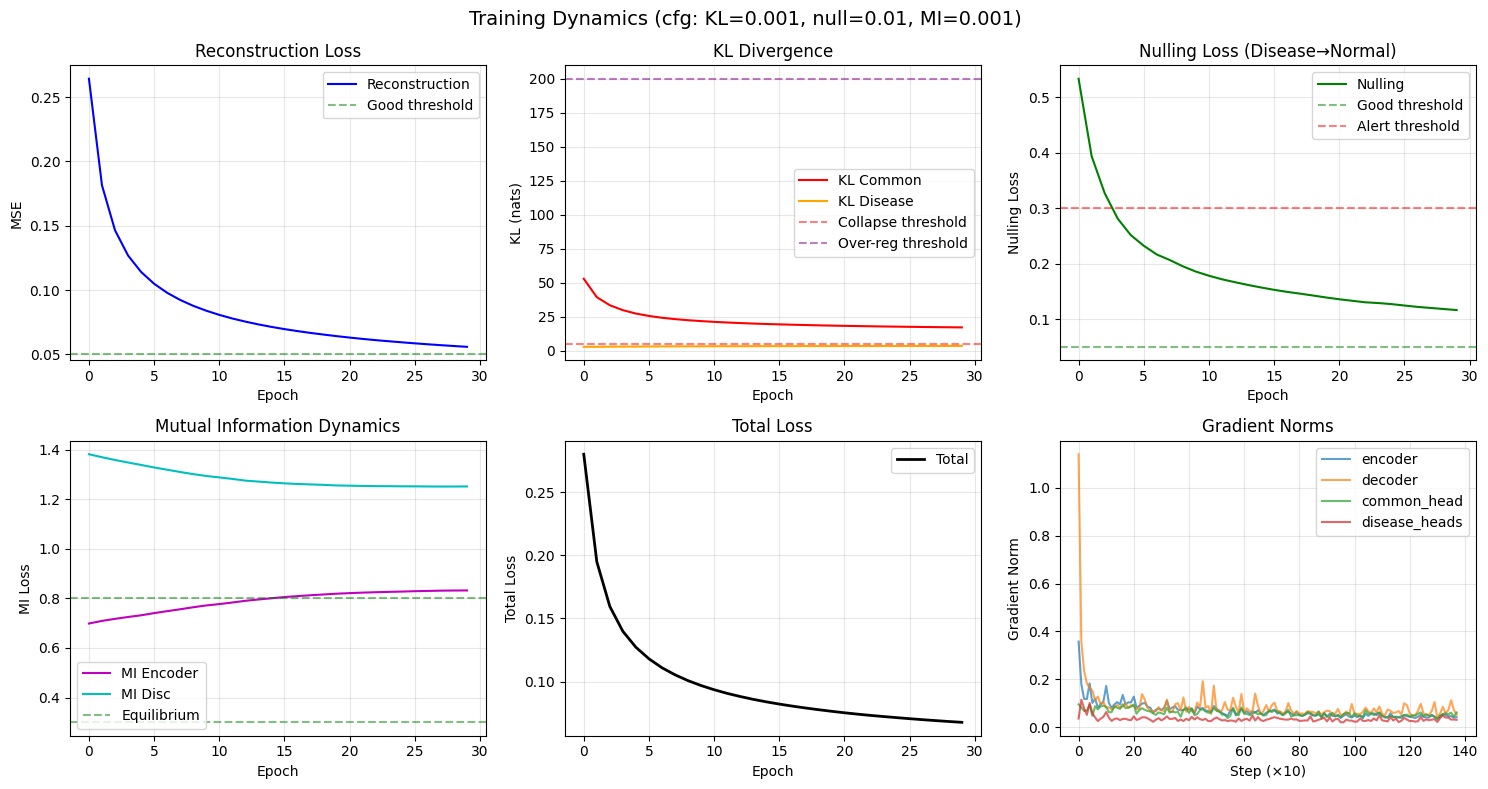


--- Loss Value Assessment ---
Reconstruction: 0.0558
  ✗ Poor - check decoder capacity, KL weight
KL Total: 20.71
  ✓ Healthy range (10-100)
Nulling: 0.1163
  ~ Moderate, may improve with training
MI Penalty: 0.8319
  ✗ MI too high - latents may be entangled

[2/5] Reconstruction Quality


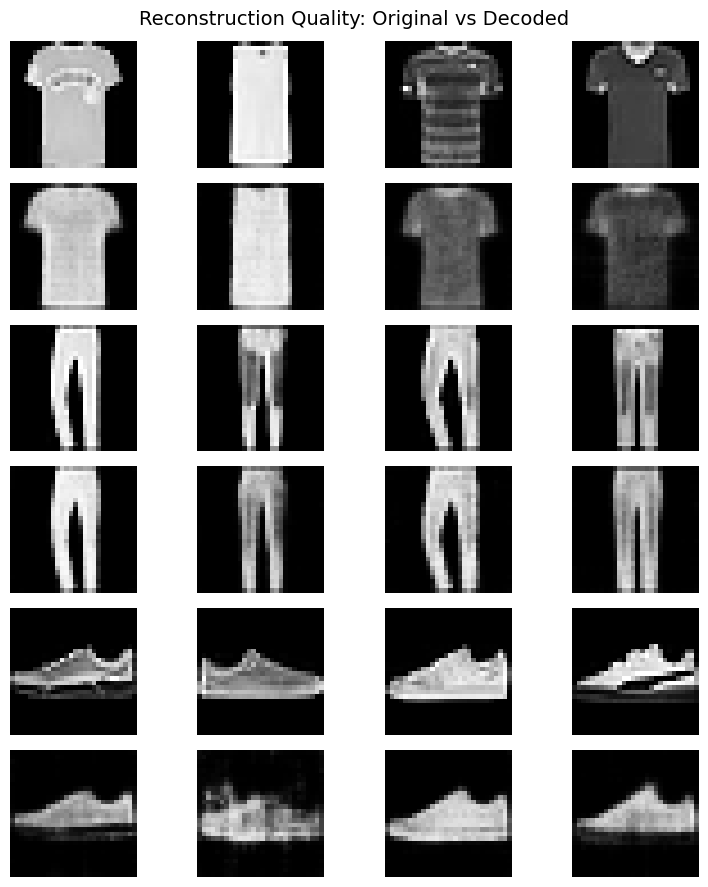


[3/5] Latent Space Structure


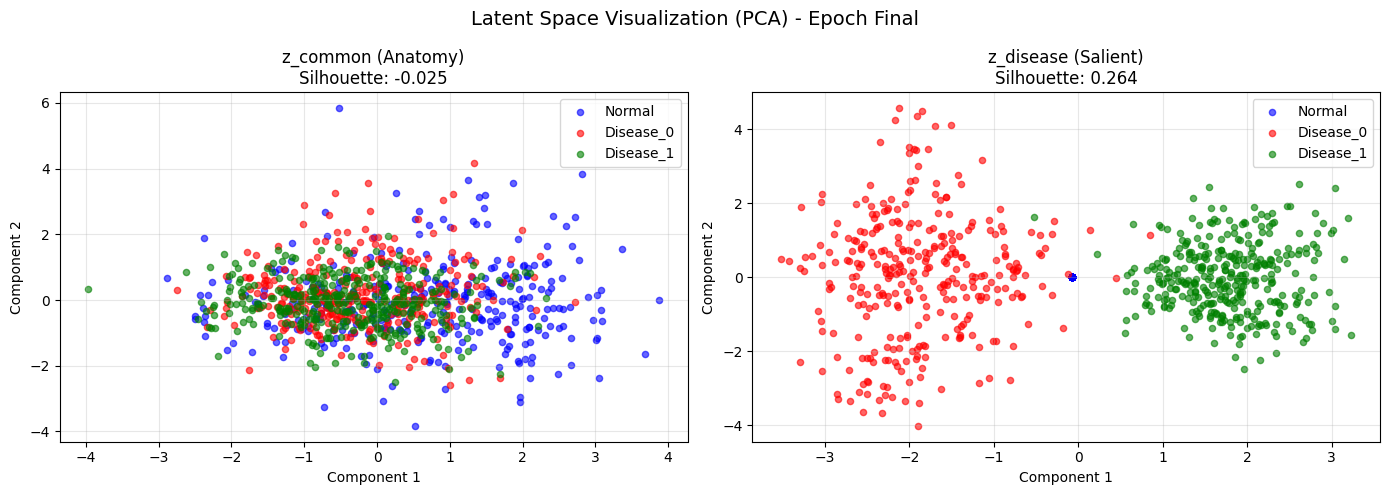


=== Latent Space Diagnostic ===
z_common silhouette: -0.025
  ✓ GOOD: No disease clustering in common space (anatomy only)
z_disease silhouette: 0.264
  ~ MODERATE: Emerging structure, may improve with more training

[4/5] Interpolation Smoothness Test


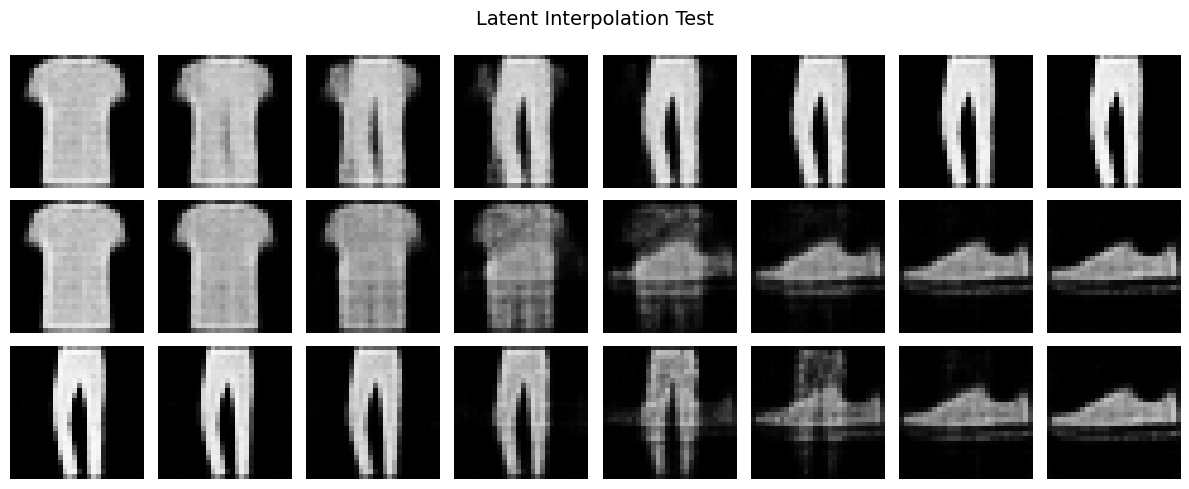


=== Interpolation Smoothness Diagnostic ===
Normal → Disease_1: spike ratio = 1.78
  ✓ GOOD: Smooth transition, Euclidean interpolation valid
Normal → Disease_2: spike ratio = 2.05
  ✗ WARNING: Spike detected - manifold has voids or curvature!
            Consider: Increase free_bits, reduce KL, check coverage
Disease_1 → Disease_2: spike ratio = 2.15
  ✗ WARNING: Spike detected - manifold has voids or curvature!
            Consider: Increase free_bits, reduce KL, check coverage

[5/5] Summary
✗ Issues detected: High reconstruction loss
  See recommendations above for fixes.


In [25]:
# === RUN HEALTHY BASELINE FIRST ===
model, mi_disc, history = run_experiment('healthy')

In [ ]:
# === EXPERIMENT: Posterior Collapse ===
# Uncomment to run:
# model_collapse, _, history_collapse = run_experiment('posterior_collapse')

In [ ]:
# === EXPERIMENT: Over-Regularization ===
# Uncomment to run:
# model_overreg, _, history_overreg = run_experiment('over_regularization')

In [ ]:
# === EXPERIMENT: Nulling Failure ===
# Uncomment to run:
# model_null, _, history_null = run_experiment('nulling_failure')

In [ ]:
# === EXPERIMENT: MI Too Weak ===
# Uncomment to run:
# model_mi_weak, _, history_mi_weak = run_experiment('mi_too_weak')

In [ ]:
# === EXPERIMENT: MI Too Strong ===
# Uncomment to run:
# model_mi_strong, _, history_mi_strong = run_experiment('mi_too_strong')

In [ ]:
# === EXPERIMENT: Manifold Voids ===
# Uncomment to run:
# model_voids, _, history_voids = run_experiment('manifold_voids')

In [ ]:
# === EXPERIMENT: Adversarial Instability ===
# Uncomment to run:
# model_adv, _, history_adv = run_experiment('adversarial_instability')

---
## 8. Side-by-Side Comparison

Compare multiple experiments to see how hyperparameters affect training dynamics.

In [ ]:
def compare_experiments(histories: Dict[str, TrainingHistory]):
    """Compare loss curves from multiple experiments."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    metrics = ['rec', 'kl_common_raw', 'nulling', 'mi_penalty', 'total']
    titles = ['Reconstruction', 'KL Common', 'Nulling', 'MI Penalty', 'Total']
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(histories)))
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes.flat[idx]
        for (name, hist), color in zip(histories.items(), colors):
            if metric in hist.epoch_losses:
                ax.plot(hist.epoch_losses[metric], label=name, color=color)
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    axes.flat[-1].axis('off')  # Empty subplot
    plt.suptitle('Experiment Comparison', fontsize=14)
    plt.tight_layout()
    plt.show()

# Example usage (after running multiple experiments):
# compare_experiments({
#     'healthy': history,
#     'collapse': history_collapse,
#     'over_reg': history_overreg,
# })

---
## Appendix: Mathematical Reference

### Loss Term Summary

| Loss | Formula | Code Variable | Gradient Flow |
|------|---------|---------------|---------------|
| **Reconstruction** | $L_{rec} = \frac{1}{N}\|x - \hat{x}\|^2_2$ | `losses['rec']` | Encoder → Heads → Decoder |
| **KL Common** | $L_{KL,c} = \frac{1}{2}\sum_j(\mu_j^2 + \sigma_j^2 - \log\sigma_j^2 - 1)$ | `losses['kl_common']` | Encoder → Common Head |
| **KL Disease** | $L_{KL,d} = \sum_d KL(q(z_d|x) \| p(z_d))$ | `losses['kl_disease']` | Encoder → Disease Heads |
| **Nulling** | $L_{null} = KL(q(z_d|x_{normal}) \| N(0, \sigma^2_{inactive}))$ | `losses['nulling']` | Encoder → Disease Heads (normals only) |
| **MI Penalty** | $L_{MI} = -\mathbb{E}[\log(1 - D(z_c, z_d))]$ | `losses['mi_penalty']` | Encoder → Both Heads |
| **MI Disc** | $L_{MI,D} = -\mathbb{E}[\log D_{joint}] - \mathbb{E}[\log(1-D_{marg})]$ | `losses['mi_disc']` | MI Discriminator |
| **Adversarial** | $L_{adv} = (D(\hat{x}) - 1)^2$ | `losses['adversarial']` | Decoder |

### Diagnostic Thresholds

| Metric | Good | Warning | Critical |
|--------|------|---------|----------|
| `rec` | <0.02 | 0.02-0.05 | >0.05 |
| `kl_total` | 10-100 | 5-10 or 100-200 | <5 (collapse) or >200 (over-reg) |
| `nulling` | <0.05 | 0.05-0.3 | >0.3 |
| `mi_penalty` | 0.3-0.8 | 0.1-0.3 or 0.8-1.5 | <0.1 or >1.5 |
| z_common silhouette | <0.1 | 0.1-0.3 | >0.3 (disease leakage) |
| z_disease silhouette | >0.5 | 0.2-0.5 | <0.2 (poor separation) |